# Unit 3 — Mixture models and EM

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Implement K-means clustering, mixtures of Gaussians and Hierarchical clustering algorithm to categorize data

Group the 1,461 days into 4 kinds of weather without using any labels. K-means gives each day to its nearest centre, a Gaussian mixture (fitted with EM) gives soft memberships, and hierarchical clustering keeps merging the two closest groups. We then compare the three.

silhouette (higher = better separated): {'K-means': 0.372, 'Gaussian mixture': 0.032, 'Hierarchical': 0.27}
GMM: days with a clear (> 90%) membership: 73%
GMM: share of completely dry days in each cluster: [0.0, 1.0, 0.0, 0.0]
  -> one flat cluster holds every dry day. Silhouette only rewards round,
     well-separated groups, so it gives the mixture a low score.

how much the methods agree (adjusted Rand index, 1 = identical):
                  K-means  Gaussian mixture  Hierarchical
K-means              1.00              0.29          0.51
Gaussian mixture     0.29              1.00          0.30
Hierarchical         0.51              0.30          1.00

what each K-means cluster looks like:
         temp_max  temp_min  wind  log_rain  rain_share
cluster                                                
0            10.5       3.4   2.2       0.3         0.3
1            11.2       5.0   5.3       0.6         0.6
2            23.6      12.7   2.8       0.1         0.2
3            12.9

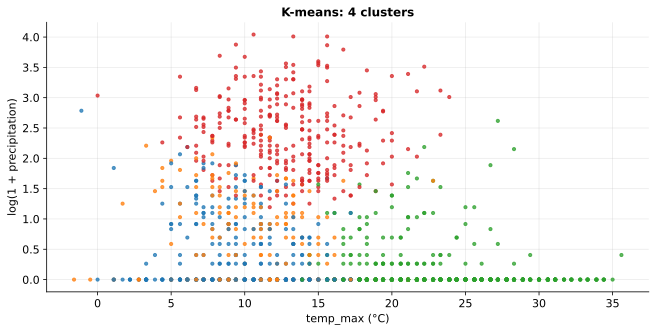

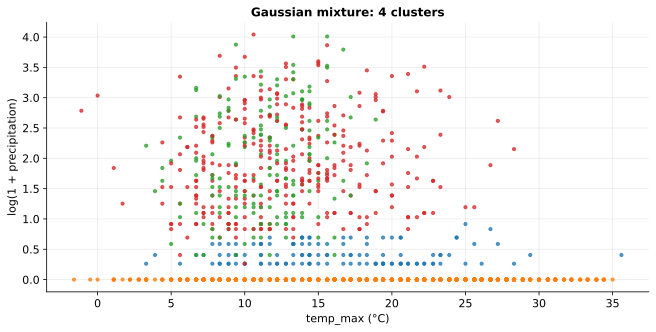

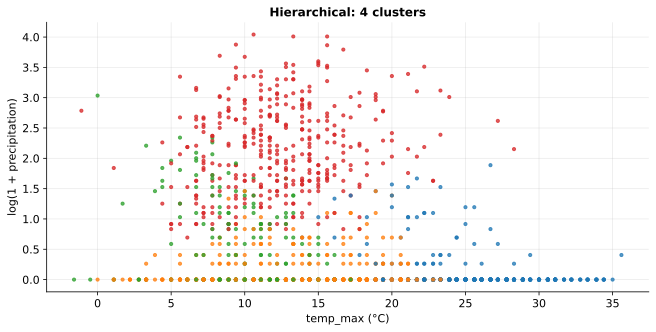

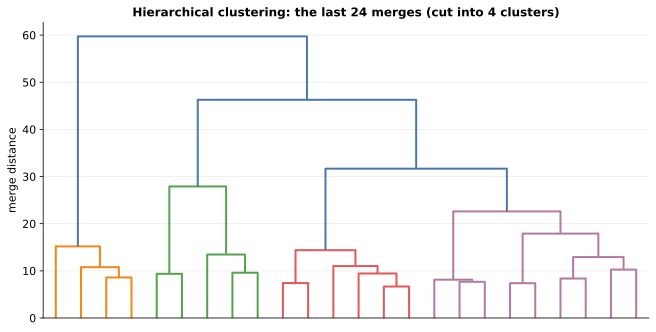

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values                                   # same scale for every column
k = 4

kmeans = KMeans(k, n_init=10, random_state=0).fit(Z)
gmm = GaussianMixture(k, n_init=3, random_state=0).fit(Z)
tree = linkage(Z, method="ward")                                        # hierarchical: merge the closest groups
found = {
    "K-means": kmeans.labels_,
    "Gaussian mixture": gmm.predict(Z),
    "Hierarchical": fcluster(tree, k, criterion="maxclust") - 1,
}

print("silhouette (higher = better separated):", {m: round(float(silhouette_score(Z, l)), 3) for m, l in found.items()})
print("GMM: days with a clear (> 90%) membership:", f"{(gmm.predict_proba(Z).max(1) > .9).mean():.0%}")
dry = (d.precipitation == 0).values
print("GMM: share of completely dry days in each cluster:", [float(dry[found["Gaussian mixture"] == j].mean().round(2)) for j in range(k)])
print("  -> one flat cluster holds every dry day. Silhouette only rewards round,\n     well-separated groups, so it gives the mixture a low score.")
print("\nhow much the methods agree (adjusted Rand index, 1 = identical):")
names = list(found)
print(pd.DataFrame([[adjusted_rand_score(found[a], found[b]) for b in names] for a in names], index=names, columns=names).round(2))
print("\nwhat each K-means cluster looks like:")
print(X.assign(cluster=found["K-means"], rain_share=d.rain).groupby("cluster").mean().round(1))

for name, labels in found.items():                                     # one picture per method
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.scatter(d.temp_max, np.log1p(d.precipitation), c=labels, cmap="tab10", vmin=0, vmax=9, s=10, alpha=.75)
    ax.set_title(f"{name}: 4 clusters"); ax.set_xlabel("temp_max (°C)"); ax.set_ylabel("log(1 + precipitation)")
    plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(tree, truncate_mode="lastp", p=24, no_labels=True, color_threshold=tree[-(k - 1), 2], ax=ax)
ax.set_title("Hierarchical clustering: the last 24 merges (cut into 4 clusters)"); ax.set_ylabel("merge distance")
plt.show()

## Practice 2 — Create a program to perform PCA

Principal component analysis finds the directions along which the days vary most: the eigenvectors of the covariance matrix. Two components keep most of the information, so every day can be drawn as a point on a flat picture.

variance explained by each component: [0.52, 0.3, 0.155, 0.024]
the first two components keep 82% of the variance

loadings (how each component mixes the original columns):
           PC1   PC2
temp_max  0.65  0.24
temp_min  0.60  0.41
wind     -0.27  0.68
log_rain -0.38  0.56


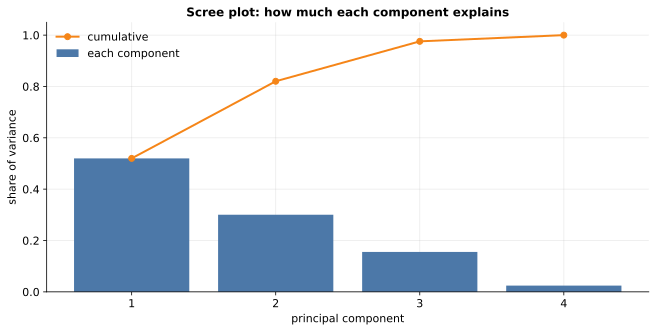

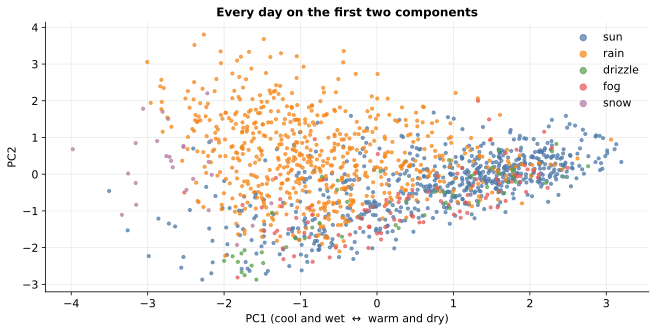

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

d = load()
X = pd.DataFrame({"temp_max": d.temp_max, "temp_min": d.temp_min, "wind": d.wind, "log_rain": np.log1p(d.precipitation)})
Z = ((X - X.mean()) / X.std()).values

values, vectors = np.linalg.eigh(np.cov(Z, rowvar=False))      # eigen-decomposition of the covariance matrix
order = values.argsort()[::-1]
values, vectors = values[order], vectors[:, order]
vectors = vectors * np.sign(vectors[0])                       # an eigenvector can point either way; make temp_max positive
scores = Z @ vectors                                             # the days expressed on the new axes
explained = values / values.sum()

print("variance explained by each component:", explained.round(3).tolist())
print(f"the first two components keep {explained[:2].sum():.0%} of the variance\n")
print("loadings (how each component mixes the original columns):")
print(pd.DataFrame(vectors[:, :2], index=X.columns, columns=["PC1", "PC2"]).round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(1, 5), explained, color="#4c78a8", label="each component")
ax.plot(range(1, 5), explained.cumsum(), "o-", color="#f58518", label="cumulative")
ax.set_xticks(range(1, 5)); ax.set_xlabel("principal component"); ax.set_ylabel("share of variance")
ax.set_title("Scree plot: how much each component explains"); ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for label in ["sun", "rain", "drizzle", "fog", "snow"]:
    m = (d.weather == label).values
    ax.scatter(scores[m, 0], scores[m, 1], s=10, alpha=.7, label=label)
ax.set_xlabel("PC1 (cool and wet  ↔  warm and dry)"); ax.set_ylabel("PC2")
ax.set_title("Every day on the first two components"); ax.legend(markerscale=2)
plt.show()